In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted!")

Mounted at /content/drive
Drive mounted!


In [2]:
!pip install scikit-image -q
!pip install opencv-python -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from skimage import filters, morphology, measure
from skimage.color import rgb2hsv
import cv2
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [3]:
np.random.seed(42)

# Simulate high resolution drone image
# 200x200 pixels = 4m x 4m field at 2cm resolution
field_size = 200

def create_drone_image(size):

    # Base healthy crop - green color
    red   = np.random.normal(80,  10, (size, size)).astype(np.uint8)
    green = np.random.normal(140, 15, (size, size)).astype(np.uint8)
    blue  = np.random.normal(60,  10, (size, size)).astype(np.uint8)

    image = np.stack([red, green, blue], axis=2)
    image = np.clip(image, 0, 255).astype(np.uint8)
    return image

def add_disease_spot(image, cx, cy, radius, disease_type):
    size = image.shape[0]
    for i in range(max(0, cx-radius), min(size, cx+radius)):
        for j in range(max(0, cy-radius), min(size, cy+radius)):
            dist = np.sqrt((i-cx)**2 + (j-cy)**2)
            if dist < radius:
                intensity = 1 - (dist / radius)
                if disease_type == 'early_blight':
                    # Brown spots with yellow halo
                    image[i,j,0] = min(255, int(image[i,j,0] + 120*intensity))
                    image[i,j,1] = max(0,   int(image[i,j,1] - 60*intensity))
                    image[i,j,2] = max(0,   int(image[i,j,2] - 30*intensity))
                elif disease_type == 'late_blight':
                    # Dark brown/black lesions
                    image[i,j,0] = max(0,   int(image[i,j,0] - 50*intensity))
                    image[i,j,1] = max(0,   int(image[i,j,1] - 80*intensity))
                    image[i,j,2] = max(0,   int(image[i,j,2] - 40*intensity))
                elif disease_type == 'yellowing':
                    # Yellow chlorosis
                    image[i,j,0] = min(255, int(image[i,j,0] + 80*intensity))
                    image[i,j,1] = min(255, int(image[i,j,1] + 20*intensity))
                    image[i,j,2] = max(0,   int(image[i,j,2] - 40*intensity))
    return image

# Create base drone image
drone_image = create_drone_image(field_size)

# Add multiple disease spots
disease_spots = [
    (30,  40,  12, 'early_blight'),
    (30,  40,  5,  'early_blight'),
    (80,  60,  8,  'late_blight'),
    (120, 150, 10, 'early_blight'),
    (160, 80,  6,  'late_blight'),
    (50,  160, 9,  'yellowing'),
    (170, 170, 7,  'early_blight'),
    (100, 30,  5,  'yellowing'),
    (145, 60,  4,  'late_blight'),
    (60,  110, 6,  'early_blight'),
]

for cx, cy, radius, dtype in disease_spots:
    drone_image = add_disease_spot(
        drone_image, cx, cy, radius, dtype)

print("DRONE IMAGE SIMULATED")
print("=" * 45)
print(f"Image size      : {field_size}x{field_size} pixels")
print(f"Ground resolution: 2cm per pixel")
print(f"Area covered    : {field_size*0.02:.1f}m x {field_size*0.02:.1f}m")
print(f"Disease spots   : {len(disease_spots)} locations")
print(f"Disease types   : Early Blight, Late Blight, Yellowing")

DRONE IMAGE SIMULATED
Image size      : 200x200 pixels
Ground resolution: 2cm per pixel
Area covered    : 4.0m x 4.0m
Disease spots   : 10 locations
Disease types   : Early Blight, Late Blight, Yellowing


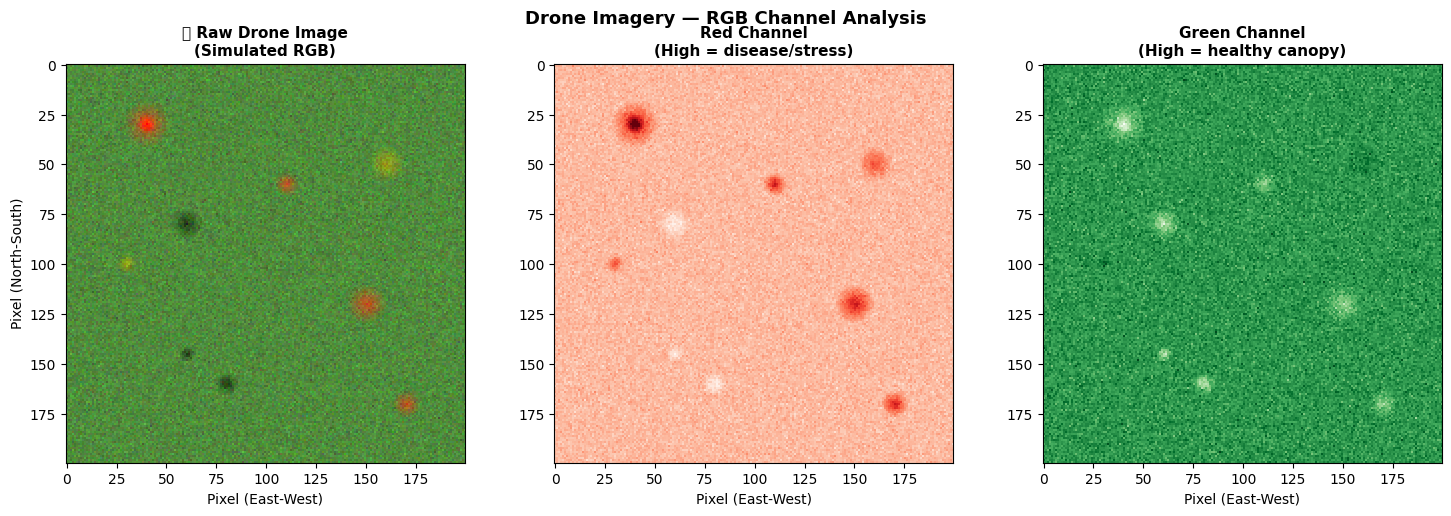

Raw drone image saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Full drone image
axes[0].imshow(drone_image)
axes[0].set_title('🚁 Raw Drone Image\n(Simulated RGB)',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel (East-West)')
axes[0].set_ylabel('Pixel (North-South)')

# Red channel
axes[1].imshow(drone_image[:,:,0], cmap='Reds')
axes[1].set_title('Red Channel\n(High = disease/stress)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel (East-West)')

# Green channel
axes[2].imshow(drone_image[:,:,1], cmap='Greens')
axes[2].set_title('Green Channel\n(High = healthy canopy)',
                   fontsize=11, fontweight='bold')
axes[2].set_xlabel('Pixel (East-West)')

plt.suptitle('Drone Imagery — RGB Channel Analysis',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drone_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print("Raw drone image saved!")

In [5]:
# ExG = Excess Green Index
# Best vegetation index for drone RGB imagery
# (Drones often don't have NIR band like satellites)
# ExG = 2*Green - Red - Blue

red_f   = drone_image[:,:,0].astype(float)
green_f = drone_image[:,:,1].astype(float)
blue_f  = drone_image[:,:,2].astype(float)

# Normalize to 0-1
red_n   = red_f   / 255.0
green_n = green_f / 255.0
blue_n  = blue_f  / 255.0

# Calculate ExG
exg = 2 * green_n - red_n - blue_n

# Calculate VARI - Visible Atmospherically Resistant Index
# Great for disease stress in RGB drone imagery
vari = (green_f - red_f) / (green_f + red_f - blue_f + 0.001)
vari = np.clip(vari, -1, 1)

print("DRONE VEGETATION INDICES")
print("=" * 45)
print(f"ExG Formula : 2*Green - Red - Blue")
print(f"ExG Mean    : {exg.mean():.3f}")
print(f"ExG Min     : {exg.min():.3f}")
print(f"ExG Max     : {exg.max():.3f}")
print()
print(f"VARI Mean   : {vari.mean():.3f}")
print(f"VARI Min    : {vari.min():.3f}")
print(f"VARI Max    : {vari.max():.3f}")
print()
print("ExG > 0.1  = Healthy green vegetation")
print("ExG < 0.0  = Diseased or bare soil")

DRONE VEGETATION INDICES
ExG Formula : 2*Green - Red - Blue
ExG Mean    : 0.541
ExG Min     : -1.016
ExG Max     : 1.051

VARI Mean   : 0.367
VARI Min    : -1.000
VARI Max    : 1.000

ExG > 0.1  = Healthy green vegetation
ExG < 0.0  = Diseased or bare soil


In [6]:
# Threshold ExG to find diseased areas
disease_mask = exg < 0.05

# Clean up noise using morphology
disease_mask_clean = morphology.remove_small_objects(
    disease_mask, min_size=20)
disease_mask_clean = morphology.binary_dilation(
    disease_mask_clean, morphology.disk(2))

# Label connected disease regions
labeled_regions = measure.label(disease_mask_clean)
regions = measure.regionprops(labeled_regions)

print("DISEASE REGION DETECTION")
print("=" * 50)
print(f"Total disease regions found : {len(regions)}")
print()
print(f"{'Region':<8} {'Area(px)':>10} {'Area(cm²)':>10} {'Severity':>10}")
print("-" * 42)

region_data = []
for i, region in enumerate(regions):
    area_px   = region.area
    area_cm2  = area_px * (2*2)
    if area_cm2 < 10:
        severity = 'Early'
    elif area_cm2 < 50:
        severity = 'Moderate'
    else:
        severity = 'Severe'

    region_data.append({
        'Region':    i+1,
        'Area_px':   area_px,
        'Area_cm2':  area_cm2,
        'Severity':  severity,
        'Centroid_x': int(region.centroid[1]),
        'Centroid_y': int(region.centroid[0]),
    })
    print(f"{i+1:<8} {area_px:>10} {area_cm2:>10} {severity:>10}")

df_regions = pd.DataFrame(region_data)

DISEASE REGION DETECTION
Total disease regions found : 3

Region     Area(px)  Area(cm²)   Severity
------------------------------------------
1             142.0      568.0     Severe
2             112.0      448.0     Severe
3              64.0      256.0     Severe


In [7]:
total_pixels    = field_size * field_size
diseased_pixels = disease_mask_clean.sum()
healthy_pixels  = total_pixels - diseased_pixels

disease_percent = (diseased_pixels / total_pixels) * 100

print("DISEASE SEVERITY ASSESSMENT")
print("=" * 45)
print(f"Total field area    : {total_pixels} pixels")
print(f"Healthy area        : {healthy_pixels} pixels ({100-disease_percent:.1f}%)")
print(f"Diseased area       : {diseased_pixels} pixels ({disease_percent:.1f}%)")
print()

if disease_percent > 30:
    severity_class = "SEVERE — Immediate action required!"
    action = "Apply fungicide across entire field"
elif disease_percent > 15:
    severity_class = "MODERATE — Targeted treatment needed"
    action = "Apply fungicide to hotspot zones only"
elif disease_percent > 5:
    severity_class = "MILD — Monitor and scout"
    action = "Weekly monitoring, prepare fungicide"
else:
    severity_class = "VERY MILD — Early detection"
    action = "Scout field, no treatment yet"

print(f"Severity Class      : {severity_class}")
print(f"Recommended Action  : {action}")
print()

# Severity by region
severe_count   = len(df_regions[df_regions['Severity']=='Severe'])
moderate_count = len(df_regions[df_regions['Severity']=='Moderate'])
early_count    = len(df_regions[df_regions['Severity']=='Early'])
print(f"Severe regions      : {severe_count}")
print(f"Moderate regions    : {moderate_count}")
print(f"Early stage regions : {early_count}")

DISEASE SEVERITY ASSESSMENT
Total field area    : 40000 pixels
Healthy area        : 39682 pixels (99.2%)
Diseased area       : 318 pixels (0.8%)

Severity Class      : VERY MILD — Early detection
Recommended Action  : Scout field, no treatment yet

Severe regions      : 3
Moderate regions    : 0
Early stage regions : 0


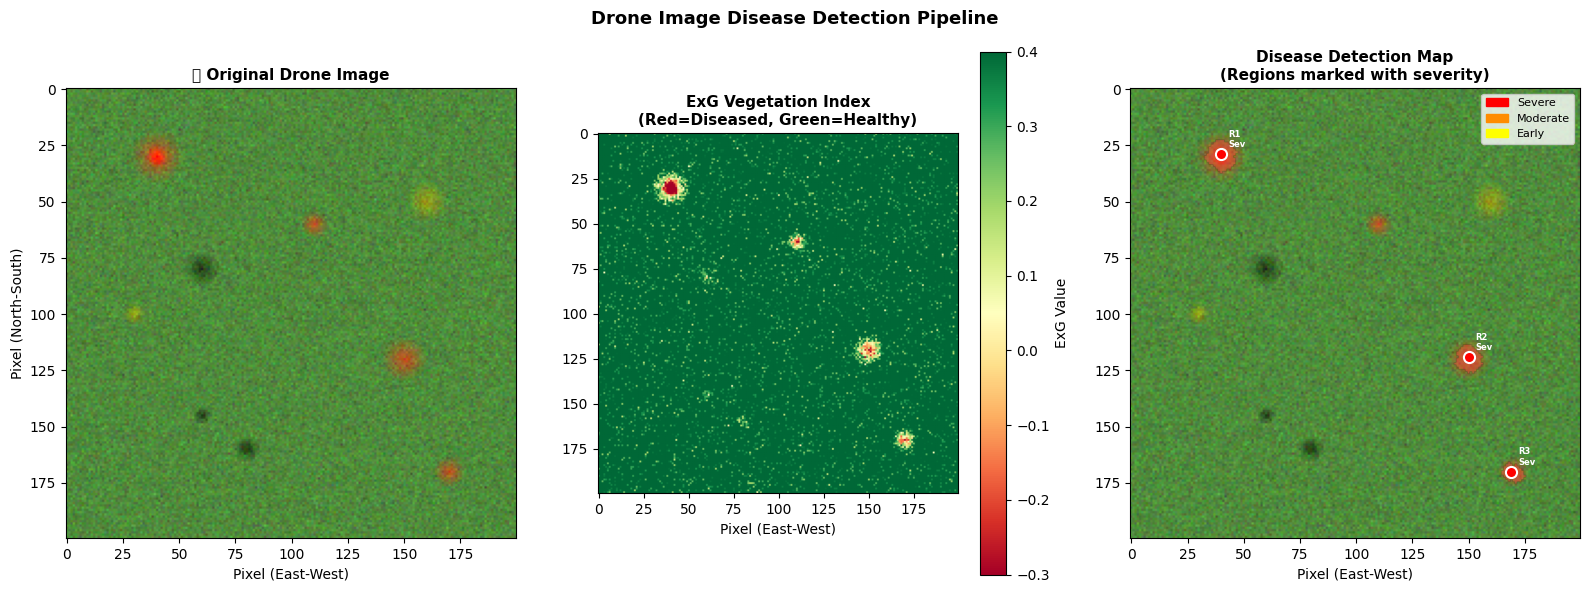

Disease map saved!


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Original drone image
axes[0].imshow(drone_image)
axes[0].set_title('🚁 Original Drone Image',
                   fontsize=11, fontweight='bold')
axes[0].set_xlabel('Pixel (East-West)')
axes[0].set_ylabel('Pixel (North-South)')

# ExG map
exg_im = axes[1].imshow(exg, cmap='RdYlGn', vmin=-0.3, vmax=0.4)
plt.colorbar(exg_im, ax=axes[1], label='ExG Value')
axes[1].set_title('ExG Vegetation Index\n(Red=Diseased, Green=Healthy)',
                   fontsize=11, fontweight='bold')
axes[1].set_xlabel('Pixel (East-West)')

# Disease map with regions marked
axes[2].imshow(drone_image)
axes[2].imshow(disease_mask_clean,
               alpha=0.5,
               cmap=mcolors.ListedColormap(['none', '#e74c3c']))

# Mark each disease region
for region in df_regions.itertuples():
    cx, cy = region.Centroid_x, region.Centroid_y
    color  = '#ff0000' if region.Severity == 'Severe' else \
             '#ff8c00' if region.Severity == 'Moderate' else '#ffff00'
    axes[2].plot(cx, cy, 'o',
                 color=color, markersize=8,
                 markeredgecolor='white',
                 markeredgewidth=1.5)
    axes[2].annotate(
        f'R{region.Region}\n{region.Severity[:3]}',
        (cx, cy),
        textcoords='offset points',
        xytext=(5, 5),
        fontsize=6,
        color='white',
        fontweight='bold'
    )

axes[2].set_title('Disease Detection Map\n(Regions marked with severity)',
                   fontsize=11, fontweight='bold')
axes[2].set_xlabel('Pixel (East-West)')

legend_elements = [
    mpatches.Patch(color='#ff0000', label='Severe'),
    mpatches.Patch(color='#ff8c00', label='Moderate'),
    mpatches.Patch(color='#ffff00', label='Early'),
]
axes[2].legend(handles=legend_elements,
               loc='upper right', fontsize=8)

plt.suptitle('Drone Image Disease Detection Pipeline',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drone_disease_map.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Disease map saved!")

In [9]:
# Calculate economic impact — this is what farmers care about!

crop = "Rice"
field_area_ha     = 1.0
yield_potential   = 6000   # kg/ha potential yield
price_per_kg      = 0.35   # USD per kg

yield_loss_percent = disease_percent * 0.8
yield_loss_kg      = yield_potential * (yield_loss_percent/100)
revenue_loss       = yield_loss_kg * price_per_kg

# Treatment costs
blanket_spray_cost   = 45   # USD per ha
targeted_spray_cost  = 45 * (disease_percent/100) * 1.5

print("ECONOMIC IMPACT ANALYSIS")
print("=" * 50)
print(f"Crop              : {crop}")
print(f"Field Area        : {field_area_ha} hectare")
print(f"Disease Coverage  : {disease_percent:.1f}% of field")
print()
print(f"YIELD IMPACT:")
print(f"  Potential yield : {yield_potential:,} kg/ha")
print(f"  Estimated loss  : {yield_loss_kg:.0f} kg/ha ({yield_loss_percent:.1f}%)")
print(f"  Revenue loss    : ${revenue_loss:.2f} per hectare")
print()
print(f"TREATMENT COST COMPARISON:")
print(f"  Blanket spraying: ${blanket_spray_cost:.2f}/ha")
print(f"  Targeted spraying: ${targeted_spray_cost:.2f}/ha")
print(f"  Cost saving     : ${blanket_spray_cost-targeted_spray_cost:.2f}/ha")
print()
print(f"NET BENEFIT OF DRONE MONITORING:")
net_benefit = revenue_loss - targeted_spray_cost
print(f"  Revenue saved   : ${revenue_loss:.2f}")
print(f"  Treatment cost  : ${targeted_spray_cost:.2f}")
print(f"  Net benefit     : ${net_benefit:.2f} per hectare")
print()
print("This analysis justifies drone investment to farmers!")

ECONOMIC IMPACT ANALYSIS
Crop              : Rice
Field Area        : 1.0 hectare
Disease Coverage  : 0.8% of field

YIELD IMPACT:
  Potential yield : 6,000 kg/ha
  Estimated loss  : 38 kg/ha (0.6%)
  Revenue loss    : $13.36 per hectare

TREATMENT COST COMPARISON:
  Blanket spraying: $45.00/ha
  Targeted spraying: $0.54/ha
  Cost saving     : $44.46/ha

NET BENEFIT OF DRONE MONITORING:
  Revenue saved   : $13.36
  Treatment cost  : $0.54
  Net benefit     : $12.82 per hectare

This analysis justifies drone investment to farmers!


In [10]:
# Convert pixel coordinates to GPS coordinates
# This is how drones create precision spray maps!

# Simulated field GPS boundaries
field_lat_min = 20.2500
field_lat_max = 20.2540
field_lon_min = 85.8300
field_lon_max = 85.8340

def pixel_to_gps(px, py, img_size,
                 lat_min, lat_max,
                 lon_min, lon_max):
    lat = lat_max - (py/img_size) * (lat_max - lat_min)
    lon = lon_min + (px/img_size) * (lon_max - lon_min)
    return round(lat, 6), round(lon, 6)

print("GPS COORDINATES OF DISEASE HOTSPOTS")
print("=" * 60)
print(f"{'Region':<8} {'Severity':<12} {'Latitude':>12} {'Longitude':>12}")
print("-" * 48)

gps_data = []
for region in df_regions.itertuples():
    lat, lon = pixel_to_gps(
        region.Centroid_x,
        region.Centroid_y,
        field_size,
        field_lat_min, field_lat_max,
        field_lon_min, field_lon_max
    )
    gps_data.append({
        'Region':    region.Region,
        'Severity':  region.Severity,
        'Latitude':  lat,
        'Longitude': lon,
        'Area_cm2':  region.Area_cm2
    })
    print(f"{region.Region:<8} {region.Severity:<12} {lat:>12} {lon:>12}")

df_gps = pd.DataFrame(gps_data)
df_gps.to_csv('/content/disease_gps_coordinates.csv', index=False)
print()
print("GPS coordinates saved!")
print("Load in Google Maps or QGIS for field navigation!")

GPS COORDINATES OF DISEASE HOTSPOTS
Region   Severity         Latitude    Longitude
------------------------------------------------
1        Severe           20.25342      85.8308
2        Severe           20.25162       85.833
3        Severe            20.2506     85.83338

GPS coordinates saved!
Load in Google Maps or QGIS for field navigation!


In [11]:
from google.colab import files

files.download('/content/drone_raw.png')
files.download('/content/drone_disease_map.png')
files.download('/content/disease_gps_coordinates.csv')

print("All files downloaded!")
print()
print()
print("Files:")
print("  → drone_raw.png")
print("  → drone_disease_map.png")
print("  → disease_gps_coordinates.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded!


Files:
  → drone_raw.png
  → drone_disease_map.png
  → disease_gps_coordinates.csv
